# Descriptive statistics

This Google Colab notebook uses `customer_data.csv` and demonstrates various descriptive statistics.

## Getting ready

Import libraries.

In [55]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


## Load the data and inspect its structure

Run the next cell and upload data file when prompted.

In [56]:
column_names = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation", "relationship", "race", "gender", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"]
train = pd.read_csv("C:/Users/gabij/Downloads/adult/adult.data",
                    names=column_names,
                    na_values="?",
                    skipinitialspace=True,
                    header=None)

test = pd.read_csv("C:/Users/gabij/Downloads/adult/adult.test",
                    names=column_names,
                    na_values="?",
                    skipinitialspace=True,
                    header=None,
                   skiprows=1)
# Target variable as 0/1: 1 = earns >50K
y_train = (train["income"] == ">50K").astype(int)
y_test = (test["income"] == ">50K").astype(int)
df = pd.read_csv("C:/Users/gabij/Downloads/adult.csv", header=None, names=column_names,
                 skipinitialspace=True, na_values="?")
df_original = df.copy()
df = df.dropna()
# Display the first five observations
display(df.head())

# Dataset dimensions
print(f"Dataset shape: {df.shape}")
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])
print("Train shape:", train.shape)
print("Test shape:", test.shape)
# Variable names and data types
print("\nVariable information:")
df.info()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Dataset shape: (30162, 15)
Number of observations: 30162
Number of variables: 15
Train shape: (32561, 15)
Test shape: (16281, 15)

Variable information:
<class 'pandas.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   fnlwgt          30162 non-null  int64
 3   education       30162 non-null  str  
 4   education_num   30162 non-null  int64
 5   marital_status  30162 non-null  str  
 6   occupation      30162 non-null  str  
 7   relationship    30162 non-null  str  
 8   race            30162 non-null  str  
 9   gender          30162 non-null  str  
 10  capital_gain    30162 non-null  int64
 11  capital_loss    30162 non-null  int64
 12  hours_per_week  30162 non-null  int64
 13  native_country  30162 non-null  str  
 14  income          30162 non-null  str  
dtypes: int64(6), str(9

#### Check for missing values

In [57]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage (%)": df.isna().mean() * 100
})

display(missing_values)

,Missing values,Missing percentage (%)
age,0,0.0
workclass,0,0.0
fnlwgt,0,0.0
education,0,0.0
education_num,0,0.0
marital_status,0,0.0
occupation,0,0.0
relationship,0,0.0
race,0,0.0
gender,0,0.0


## Descriptive statistics

#### Descriptive statistics for numerical variables

In [58]:
numeric_columns = [ "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

# Basic descriptive statistics
numeric_statistics = df[numeric_columns].describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
age,30162.0,38.437902,13.134665,17.0,28.00,37.0,47.0,90.0
fnlwgt,30162.0,189793.833930,105652.971529,13769.0,117627.25,178425.0,237628.5,1484705.0
education_num,30162.0,10.121312,2.549995,1.0,9.00,10.0,13.0,16.0
capital_gain,30162.0,1092.007858,7406.346497,0.0,0.00,0.0,0.0,99999.0
capital_loss,30162.0,88.372489,404.298370,0.0,0.00,0.0,0.0,4356.0
hours_per_week,30162.0,40.931238,11.979984,1.0,40.00,40.0,45.0,99.0


#### More detailed descriptive statistics

In [59]:
descriptive_statistics = []

for column in numeric_columns:

    data = pd.to_numeric(df[column], errors="coerce").dropna()

    # Mode
    mode_values = data.mode()

    # If there is more than one mode, display all modes
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    else:
        mode = ", ".join(
            [f"{value:.4f}" for value in mode_values]
        )

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # Minimum and maximum
    minimum = data.min()
    maximum = data.max()

    # Range and interquartile range
    data_range = maximum - minimum
    iqr = q3 - q1

    # Add results
    descriptive_statistics.append({
        "Variable": column,
        "Mean": data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": data.var(),
        "Standard Deviation": data.std(),
        "Skewness": data.skew(),
        "Kurtosis": data.kurt()
    })

# Create the summary table
descriptive_statistics = pd.DataFrame(descriptive_statistics)

# Display the results
display(descriptive_statistics)

,Variable,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,38.437902,37.0,36,17,28.00,37.0,47.0,90,73,19.00,1.725194e+02,13.134665,0.530228,-0.144674
1,fnlwgt,189793.833930,178425.0,203488,13769,117627.25,178425.0,237628.5,1484705,1470936,120001.25,1.116255e+10,105652.971529,1.459220,6.394133
2,education_num,10.121312,10.0,9,1,9.00,10.0,13.0,16,15,4.00,6.502474e+00,2.549995,-0.305379,0.643723
3,capital_gain,1092.007858,0.0,0,0,0.00,0.0,0.0,99999,99999,0.00,5.485397e+07,7406.346497,11.902682,153.666375
4,capital_loss,88.372489,0.0,0,0,0.00,0.0,0.0,4356,4356,0.00,1.634572e+05,404.298370,4.526380,19.510871
5,hours_per_week,40.931238,40.0,40,1,40.00,40.0,45.0,99,98,5.00,1.435200e+02,11.979984,0.330869,3.167888


#### Frequency tables for categorical variables

In [60]:
categorical_columns = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native_country"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = df[column].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(df) * 100
    )

    display(frequency_table)


workclass


,Frequency,Percentage (%)
workclass,,
Private,22286,73.887673
Self-emp-not-inc,2499,8.285260
Local-gov,2067,6.852994
State-gov,1279,4.240435
Self-emp-inc,1074,3.560772
Federal-gov,943,3.126451
Without-pay,14,0.046416



education


,Frequency,Percentage (%)
education,,
HS-grad,9840,32.623831
Some-college,6678,22.140442
Bachelors,5044,16.723029
Masters,1627,5.394205
Assoc-voc,1307,4.333267
11th,1048,3.474571
Assoc-acdm,1008,3.341953
10th,820,2.718653
7th-8th,557,1.846695



marital_status


...

,Frequency,Percentage (%)
race,,
White,25933,85.979046
Black,2817,9.339566
Asian-Pac-Islander,895,2.967310
Amer-Indian-Eskimo,286,0.948213
Other,231,0.765864



gender


,Frequency,Percentage (%)
gender,,
Male,20380,67.568464
Female,9782,32.431536



native_country


,Frequency,Percentage (%)
native_country,,
United-States,27504,91.187587
Mexico,610,2.022412
Philippines,188,0.623301
Germany,128,0.424375
Puerto-Rico,109,0.361382
Canada,107,0.354751
India,100,0.331543
El-Salvador,100,0.331543
Cuba,92,0.305020


#### Cross tabulations (Crosstabs)

In [61]:
crosstab_pairs = [
    ("education", "income"),
    ("marital_status", "income"),
    ("relationship", "income")
]

for row_variable, column_variable in crosstab_pairs:

    print("\n" + "=" * 70)
    print(
        f"Crosstab (frequencies): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab = pd.crosstab(
        df[row_variable],
        df[column_variable]
    )

    display(crosstab)

    print("\n" + "=" * 70)
    print(
        f"Crosstab (total percentages): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab_total_percent = pd.crosstab(
        df[row_variable],
        df[column_variable],
        normalize="all"
    ) * 100

    display(crosstab_total_percent.round(2))



Crosstab (frequencies): education × income


income,<=50K,>50K
education,,
10th,761,59
11th,989,59
12th,348,29
1st-4th,145,6
5th-6th,276,12
7th-8th,522,35
9th,430,25
Assoc-acdm,752,256
Assoc-voc,963,344



Crosstab (total percentages): education × income


income,<=50K,>50K
education,,
10th,2.52,0.20
11th,3.28,0.20
12th,1.15,0.10
1st-4th,0.48,0.02
5th-6th,0.92,0.04
7th-8th,1.73,0.12
9th,1.43,0.08
Assoc-acdm,2.49,0.85
Assoc-voc,3.19,1.14



Crosstab (frequencies): marital_status × income


...

income,<=50K,>50K
marital_status,,
Divorced,12.47,1.50
Married-AF-spouse,0.04,0.03
Married-civ-spouse,25.42,21.22
Married-spouse-absent,1.12,0.10
Never-married,30.69,1.56
Separated,2.89,0.22
Widowed,2.48,0.27



Crosstab (frequencies): relationship × income


income,<=50K,>50K
relationship,,
Husband,6784,5679
Not-in-family,6903,823
Other-relative,854,35
Own-child,4402,64
Unmarried,2999,213
Wife,712,694



Crosstab (total percentages): relationship × income


income,<=50K,>50K
relationship,,
Husband,22.49,18.83
Not-in-family,22.89,2.73
Other-relative,2.83,0.12
Own-child,14.59,0.21
Unmarried,9.94,0.71
Wife,2.36,2.30


#### z-scores

In [62]:
# Calculate z-scores for all numerical variables

z_scores = pd.DataFrame(
    stats.zscore(
        df[numeric_columns],
        nan_policy="omit"
    ),
    columns=numeric_columns,
    index=df.index
)

print("z-scores for the numerical variables:")
display(z_scores.head())


# z-scores summary

z_score_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Mean of z-scores": [
        z_scores[column].mean()
        for column in numeric_columns
    ],
    "Std of z-scores": [
        z_scores[column].std()
        for column in numeric_columns
    ],
    "Minimum z-score": [
        z_scores[column].min()
        for column in numeric_columns
    ],
    "Maximum z-score": [
        z_scores[column].max()
        for column in numeric_columns
    ]
})

display(z_score_summary.round(4))

z-scores for the numerical variables:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.042796,-1.062722,1.128918,0.146092,-0.218586,-0.077734
1,0.880288,-1.007871,1.128918,-0.147445,-0.218586,-2.331531
2,-0.033340,0.244693,-0.439738,-0.147445,-0.218586,-0.077734
3,1.108695,0.425240,-1.224066,-0.147445,-0.218586,-0.077734
4,-0.794697,1.406658,1.128918,-0.147445,-0.218586,-0.077734


,Variable,Mean of z-scores,Std of z-scores,Minimum z-score,Maximum z-score
0,age,0.0,1.0,-1.6322,3.9257
1,fnlwgt,0.0,1.0,-1.6661,12.2565
2,education_num,-0.0,1.0,-3.5771,2.3054
3,capital_gain,-0.0,1.0,-0.1474,13.3546
4,capital_loss,0.0,1.0,-0.2186,10.5558
5,hours_per_week,-0.0,1.0,-3.3332,4.8472


#### Detecting outliers using z-scores

In [63]:
Z_THRESHOLD = 3

z_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

for column in numeric_columns:
    z_outlier_flags[column] = z_scores[column].abs() > Z_THRESHOLD

# Number of potential outliers for each variable
z_outlier_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Potential outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

z_outlier_summary["Percentage (%)"] = (
    z_outlier_summary["Potential outliers"]
    / len(df) * 100
)

display(z_outlier_summary.round(2))


# z-score outlier observations

for column in numeric_columns:

    outlier_indices = z_outlier_flags.index[
        z_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"z-score outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["age", column]
        ].copy()

        outlier_table["z-score"] = z_scores.loc[
            outlier_indices,
            column
        ]

        display(
            outlier_table.sort_values(
                "z-score"
            )
        )

    else:

        print(
            f"\n{column}: No observations with |z| > {Z_THRESHOLD}."
        )

,Variable,Potential outliers,Percentage (%)
0,age,120,0.40
1,fnlwgt,322,1.07
2,education_num,196,0.65
3,capital_gain,198,0.66
4,capital_loss,1381,4.58
5,hours_per_week,402,1.33



z-score outliers: age


,age,age,z-score
978,78,78,3.012087
2684,78,78,3.012087
6035,78,78,3.012087
14884,78,78,3.012087
13209,78,78,3.012087
...,...,...,...
24043,90,90,3.925715
28463,90,90,3.925715
31030,90,90,3.925715
32277,90,90,3.925715



z-score outliers: fnlwgt


,age,fnlwgt,z-score
28574,38,506830,3.000781
6649,34,506858,3.001046
40,31,507875,3.010672
1883,27,508336,3.015035
8489,24,508548,3.017042
...,...,...,...
8258,35,1226583,9.813319
15569,29,1268339,10.208544
16739,45,1366120,11.134052
18138,39,1455435,11.979428


...

,age,capital_gain,z-score
18847,73,25124,3.244837
22462,68,25124,3.244837
6519,51,25236,3.259960
704,46,25236,3.259960
11826,59,25236,3.259960
...,...,...,...
31111,22,99999,13.354578
31972,43,99999,13.354578
31828,47,99999,13.354578
32238,47,99999,13.354578



z-score outliers: capital_loss


,age,capital_loss,z-score
203,42,1340,3.095853
31324,37,1340,3.095853
1518,25,1340,3.095853
20870,44,1340,3.095853
2630,42,1340,3.095853
...,...,...,...
11902,34,3770,9.106365
15942,38,3770,9.106365
23802,41,3900,9.427915
20416,54,3900,9.427915



z-score outliers: hours_per_week


,age,hours_per_week,z-score
24284,57,1,-3.333218
25078,74,1,-3.333218
20909,77,1,-3.333218
22960,21,1,-3.333218
19750,23,1,-3.333218
...,...,...,...
9811,28,99,4.847229
1887,55,99,4.847229
9831,67,99,4.847229
31681,43,99,4.847229


#### Detecting outliers using the IQR method

In [64]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["occupation", column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,28.00,47.0,19.00,-0.500,75.500,169,0.5603
1,fnlwgt,117627.25,237628.5,120001.25,-62374.625,417630.375,903,2.9938
2,education_num,9.00,13.0,4.00,3.000,19.000,196,0.6498
3,capital_gain,0.00,0.0,0.00,0.000,0.000,2538,8.4146
4,capital_loss,0.00,0.0,0.00,0.000,0.000,1427,4.7311
5,hours_per_week,40.00,45.0,5.00,32.500,52.500,7953,26.3676



IQR outliers: age


,occupation,age
100,Exec-managerial,76
324,Craft-repair,76
4196,Prof-specialty,76
3633,Protective-serv,76
5009,Protective-serv,76
...,...,...
28463,Craft-repair,90
24043,Exec-managerial,90
32277,Adm-clerical,90
31030,Machine-op-inspct,90



IQR outliers: fnlwgt


,occupation,fnlwgt
3258,Handlers-cleaners,417657
29837,Other-service,417668
17514,Prof-specialty,417668
20973,Handlers-cleaners,417668
28163,Prof-specialty,417668
...,...,...
8258,Sales,1226583
15569,Tech-support,1268339
16739,Other-service,1366120
18138,Craft-repair,1455435


...

,occupation,capital_gain
6271,Adm-clerical,114
4716,Other-service,114
27275,Other-service,114
19855,Adm-clerical,114
22815,Craft-repair,114
...,...,...
1482,Sales,99999
25372,Other-service,99999
24510,Exec-managerial,99999
24638,Sales,99999



IQR outliers: capital_loss


,occupation,capital_loss
20265,Machine-op-inspct,155
11279,Adm-clerical,213
17280,Tech-support,213
28960,Prof-specialty,213
3667,Exec-managerial,213
...,...,...
15942,Adm-clerical,3770
11902,Other-service,3770
23802,Prof-specialty,3900
20416,Machine-op-inspct,3900



IQR outliers: hours_per_week


,occupation,hours_per_week
20909,Adm-clerical,1
25078,Other-service,1
22960,Machine-op-inspct,1
11451,Machine-op-inspct,1
24284,Exec-managerial,1
...,...,...
29751,Other-service,99
29187,Other-service,99
4308,Farming-fishing,99
22720,Sales,99


#### Compare the two outlier-detection methods

In [65]:
outlier_comparison = pd.DataFrame({
    "Variable": numeric_columns,
    "z-score outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ],
    "IQR outliers": [
        iqr_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

outlier_comparison["Difference"] = (
    outlier_comparison["z-score outliers"]
    - outlier_comparison["IQR outliers"]
)

display(outlier_comparison)

,Variable,z-score outliers,IQR outliers,Difference
0,age,120,169,-49
1,fnlwgt,322,903,-581
2,education_num,196,196,0
3,capital_gain,198,2538,-2340
4,capital_loss,1381,1427,-46
5,hours_per_week,402,7953,-7551


#### Box-and-whisker diagram (boxplot)

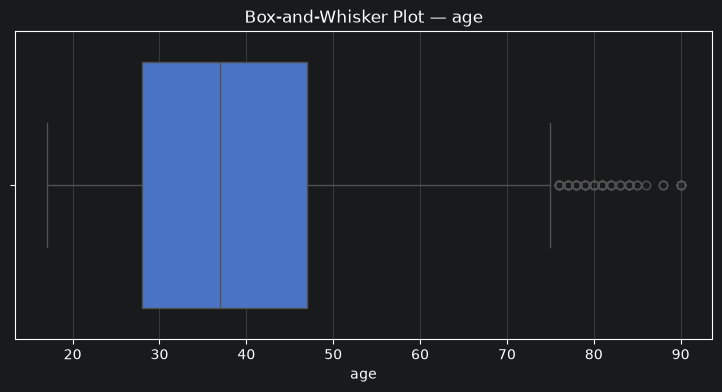

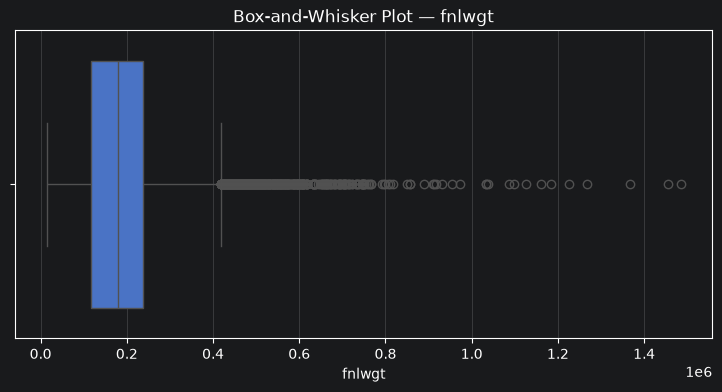

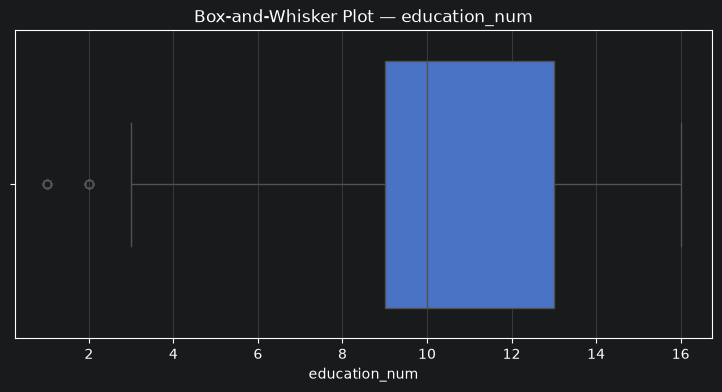

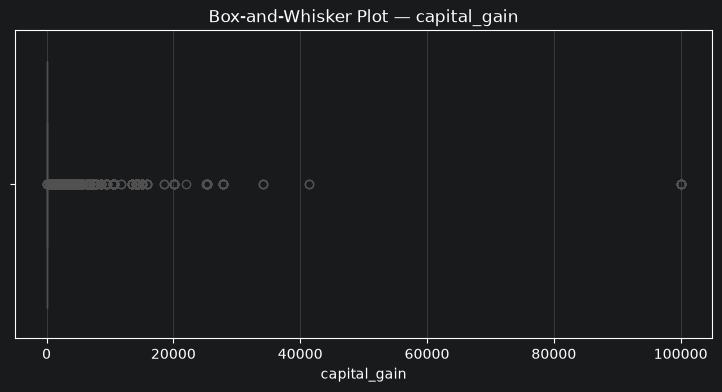

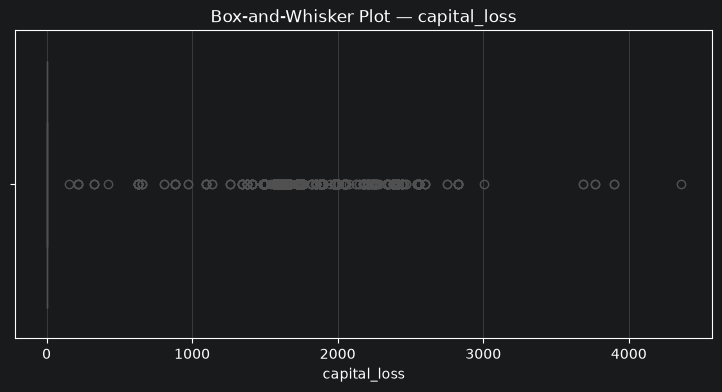

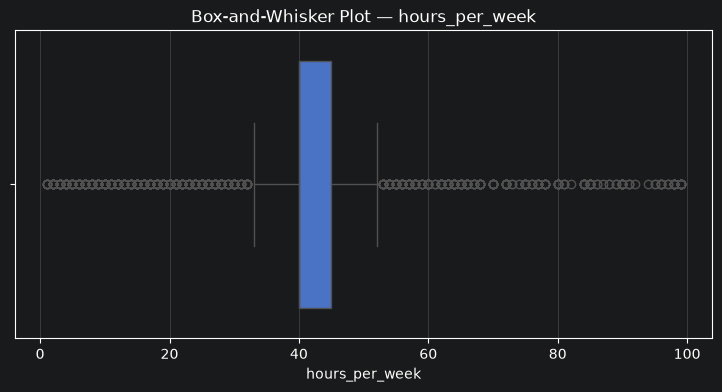

In [66]:
for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Box-and-Whisker Plot — {column}"
    )

    plt.xlabel(column)
    plt.grid(
        True,
        axis="x",
        alpha=0.3
    )

    plt.show()

#### Correlation coefficient (r)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.0000,-0.0765,0.0435,0.0802,0.0602,0.1016
fnlwgt,-0.0765,1.0000,-0.0450,0.0004,-0.0097,-0.0229
education_num,0.0435,-0.0450,1.0000,0.1244,0.0796,0.1525
capital_gain,0.0802,0.0004,0.1244,1.0000,-0.0322,0.0804
capital_loss,0.0602,-0.0097,0.0796,-0.0322,1.0000,0.0524
hours_per_week,0.1016,-0.0229,0.1525,0.0804,0.0524,1.0000


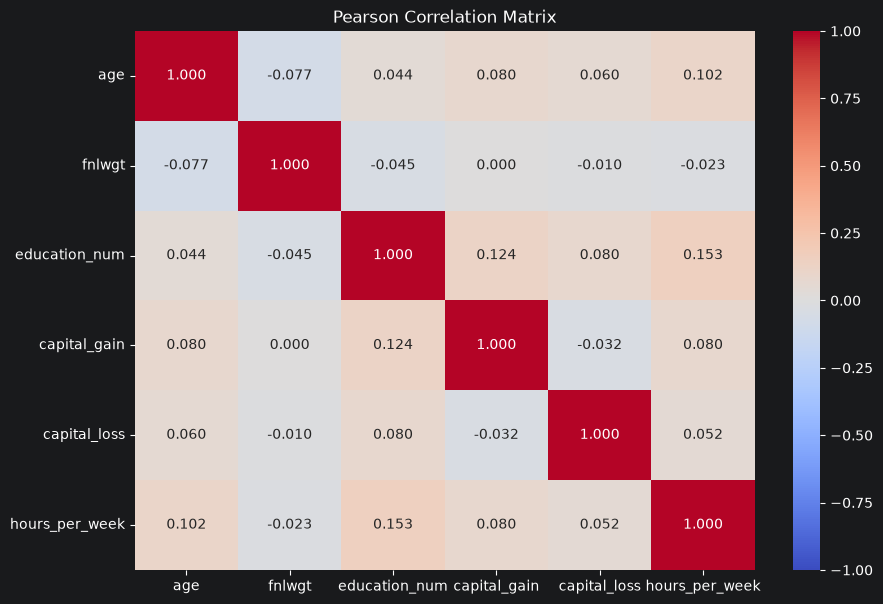

In [67]:

# Correlation matrix
correlation_matrix = df[numeric_columns].corr(method="pearson")

display(correlation_matrix.round(4))

# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

# Data Encoding

In [68]:
from sklearn.preprocessing import TargetEncoder

# Target variable as 0/1: 1 = earns >50K
y_train = (train["income"] == ">50K").astype(int)
y_test = (test["income"] == ">50K").astype(int)

In [69]:
def encode(data):
    data = data.copy()

    # Binary columns
    data["gender"] = (data["gender"] == "Male").astype(int)
    data["is_us"] = (data["native_country"] == "United-States").astype(int)

    # Drop columns not needed (education is covered by education_num)
    data = data.drop(columns=["education", "native_country", "fnlwgt", "income"],
                     errors="ignore")

    # One-hot encode the remaining text columns
    return pd.get_dummies(
        data,
        columns=["workclass", "marital_status", "occupation", "relationship", "race"],
        drop_first=True,
        dtype=int,
    )

X_train = encode(train)
X_test = encode(test)

# Make sure test has exactly the same columns as train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print(X_train.dtypes.value_counts())   # should be all numbers, no 'object'/'str'
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Missing values:", X_train.isna().sum().sum())
print("Non-numeric columns:", X_train.select_dtypes(exclude="number").columns.tolist())
print("Share earning >50K — train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

X_train shape: (32561, 42)
int64    42
Name: count, dtype: int64
X_train: (32561, 42)  X_test: (16281, 42)
Missing values: 0
Non-numeric columns: []
Share earning >50K — train: 0.241  test: 0.0


# Hypothesis testing

In [70]:
ALPHA = 0.05

def decision(p_value, alpha=ALPHA):
    return "Reject H0" if p_value < alpha else "Do not reject H0"

def print_result(test_name, h0, h1, statistic_name, statistic, p_value, alpha=ALPHA):
    print("=" * 80)
    print(test_name)
    print("-" * 80)
    print("H0:", h0)
    print("H1:", h1)
    print(f"{statistic_name} = {statistic:.4f}")
    print(f"p-value = {p_value:.6f}")
    print(f"alpha = {alpha}")
    print("Decision:", decision(p_value, alpha))
    if p_value < alpha:
        print("Interpretation: There is statistically significant evidence against H0.")
    else:
        print("Interpretation: There is not sufficient statistical evidence against H0.")


In [71]:
x = df["hours_per_week"].sample(5000, random_state=42)

stat, p_value = stats.shapiro(x)

print_result(
    test_name = "Shapiro-Wilk test for normality",
    h0 = "The hours per week are normally distributed ",
    h1 = "The hours per week are not normally distributed",
    statistic_name = "w",
    statistic = stat,
    p_value = p_value
)

Shapiro-Wilk test for normality
--------------------------------------------------------------------------------
H0: The hours per week are normally distributed 
H1: The hours per week are not normally distributed
w = 0.8908
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.


One sample t-test

In [72]:
x = df["hours_per_week"]
t_stat, p_value = stats.ttest_1samp(x, popmean=40)
print_result("One-sample t-test",
             "μ = 40 hours", "μ ≠ 40 hours",
             "t", t_stat, p_value)
print(f"Sample mean = {x.mean():.2f}")

# 3. Two groups: do men and women work different hours?
men = df.loc[df["gender"] == "Male", "hours_per_week"]
women = df.loc[df["gender"] == "Female", "hours_per_week"]
u_stat, p_value = stats.mannwhitneyu(men, women)
print_result("Mann-Whitney U test",
             "Hours per week do not differ between men and women",
             "Hours per week differ between men and women",
             "U", u_stat, p_value)
print(f"Median: men = {men.median()}, women = {women.median()}")

# 4. Two categorical variables: is income related to education?
table = pd.crosstab(df["education"], df["income"])
chi2, p_value, dof, expected = stats.chi2_contingency(table)
print_result("Chi-square test of independence",
             "Income level is independent of education",
             "Income level depends on education",
             "χ²", chi2, p_value)

One-sample t-test
--------------------------------------------------------------------------------
H0: μ = 40 hours
H1: μ ≠ 40 hours
t = 13.5000
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Sample mean = 40.93
Mann-Whitney U test
--------------------------------------------------------------------------------
H0: Hours per week do not differ between men and women
H1: Hours per week differ between men and women
U = 130469142.5000
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against H0.
Median: men = 40.0, women = 40.0
Chi-square test of independence
--------------------------------------------------------------------------------
H0: Income level is independent of education
H1: Income level depends on education
χ² = 4070.3816
p-value = 0.000000
alpha = 0.05
Decision: Reject H0
Interpretation: There is statistically significant evidence against 